# Chapter 5: Generate Images with Diffusion Models


Open in Colab:    
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1htPAwH54cSX-PzadY3VX8ccvpC07-5-W?usp=sharing)

This chapter covers:

* How the forward diffusion process gradually adds noise to images
* How the reverse diffusion process iteratively removes noise to create a clean image
* Training a denoising U-Net model
* Using the trained U-Net to generate clothing-item images

Broadly speaking, there are two ways to generate images from text prompts: vision transformers (ViT) and diffusion models. In the first method, we divide an image into multiple patches and treat each patch as an element in a sequence. As a result, image generation becomes a sequence prediction problem. When generating an image based on a text prompt, we ask the trained ViT to first predict the top left patch. In the next iteration, we feed the first patch, along with the text prompt, to the ViT and ask it to predict the second patch. We repeat the process until we have all the needed patches in the image.

The second way to generate images based on text descriptions is through diffusion models. We start with an image with pure noise. We ask the trained diffusion model to denoise it slightly, conditional on the text prompt. The result is a less noisy image. We repeat the process many times until we obtain a clean image that matches the text prompt. Diffusion models have become the go-to generative model by learning progressively removing noise from noisy images. They form the foundation of the state-of-the-art text-to-image models, including Imagen, DALL-E 2 (though not DALL-E), and Stable Diffusion

This chapter discusses the basic idea behind diffusion models. Understanding the diffusion mechanism is particularly crucial for creating text-to-image models, as diffusion models form the foundation of many leading text-to-image models. For this reason, you will start by building and training a diffusion model to generate grayscale clothing-item images in this chapter. This will provide you with a deep understanding of the forward diffusion process, where noise is incrementally added to images until they become random noise. Subsequently, you will train a model to reverse the diffusion process by gradually removing noise from images until the model can generate a new, clean image from random noise, resembling those in the training dataset. 

Along the way, you'll also learn different diffusion schedules that dictate how noise is added over time during the forward process. Different schedules, such as linear and cosine, impact both efficiency and model performance. A linear schedule gradually increases the noise level in each time step by a fixed, linearly increasing amount. Mathematically, it defines the variance of noise added in each time step as an increasing linear function of time. The linear noise schedule is simple and commonly used due to ease of implementation. The cosine schedule adjusts the noise variance in each time step using a cosine function. This leads to a non-linear progression where noise increases more gradually at first and then accelerates. The cosine schedule helps maintain finer details in initial diffusion steps, which can enhance model performance and output quality.

By the end of this chapter, you will have built a solid foundation in diffusion models, equipping you to tackle more complex tasks in text-to-image generation. You will also gain practical experience with key concepts such as forward diffusion, reverse diffusion, and noise schedules—all of which are pivotal for mastering state-of-the-art generative AI techniques.

# 1.    The Forward Diffusion Process
The idea of diffusion-based models is as follows. Imagine you want to train a diffusion model to generate high-resolution images. You first acquire a set of images for training. You'll gradually introduce small amounts of random noise into these images. This process is known as forward diffusion. After many steps of adding noise, the training images become pure random noise.

You'll then train a model to reverse this process, a process known as the reverse diffusion process (or the denoising process). Specifically, you'll start with random noise images and progressively reduce the noise until the images are indistinguishable from those in the original training set. The trained diffusion model can use random noise images as a starting point. It gradually eliminates noise from the image over many iterations until it generates a clean image. This is the underlying principle of diffusion-based models.

In this section, you will first explore the theoretical foundations of diffusion-based models. Then, you will explore two different ways of noise scheduling: the linear noise schedule and the cosine noise schedule. You'll compare them side by side to see how noise is added to images until they become random noise images, similar to snowflakes on a TV screen. 

## 1.1 How Diffusion Models Work



## 1.2 Visualize the forward diffusion process




In [1]:
import torch

# assuming 1000 time steps
T=1000
# relative timesteps [0/1000, 1/1000,...,1000/1000]
t=torch.arange(0, T + 1,dtype=torch.float32)/T
def linear_scheduler():
    # values of beta1 and beta2
    beta1, beta2 = 0.0001, 0.02
    # beta_t increses linearly with t
    beta_t = (beta2 - beta1) * t  + beta1
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    # define alphabar_t
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    # weight on x0
    sqrtab = torch.sqrt(alphabar_t)
    # weight on noise
    sqrtmab = torch.sqrt(1 - alphabar_t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

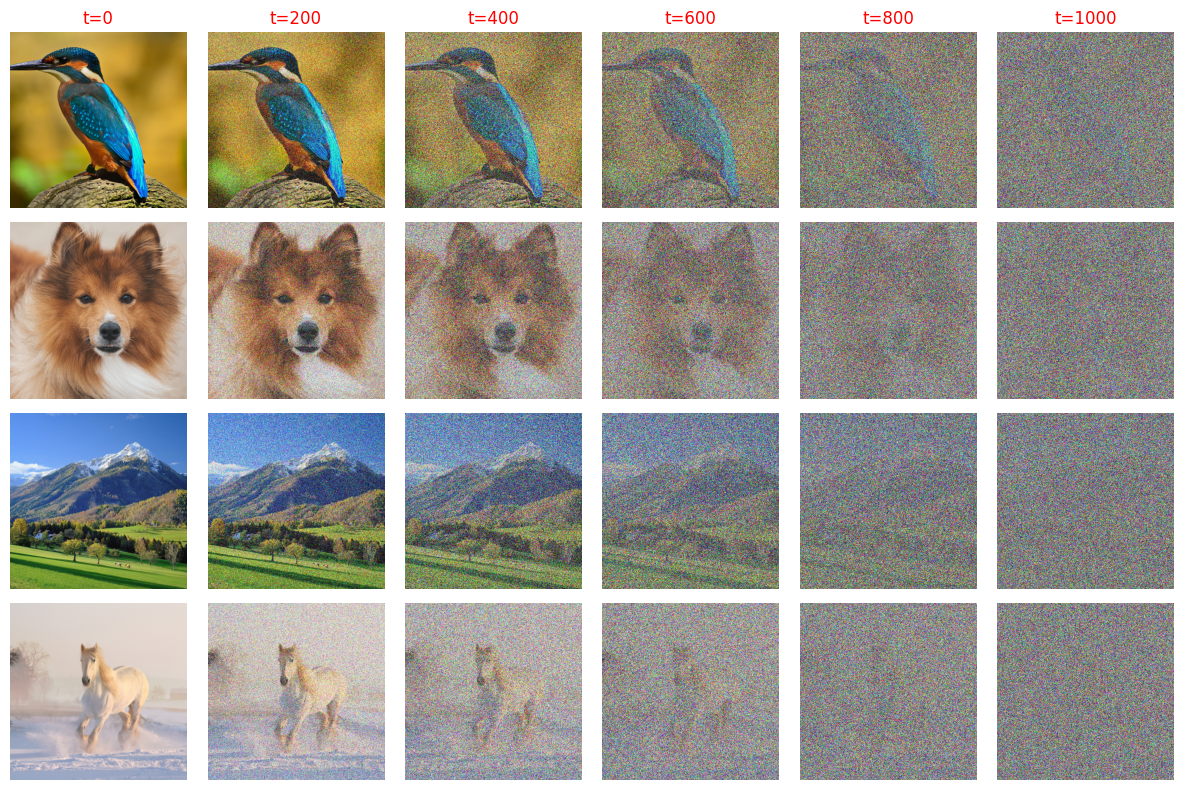

In [2]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
def linear_noisy_image(image,timestep):    #A
    alphabar_t=linear_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)
imgs=[]
for name in ["bird","dog","mountains","horse"]:
    img=np.array(PIL.Image.open(f"files/{name}.png"))
    img=torch.tensor(2*(img/255)-1)
    for timestep in [0,200,400,600,800,1000]:    #B
        imgs.append(linear_noisy_image(img,timestep)/2+0.5)
plt.figure(figsize=(12,8),dpi=100)
for i in range(24):
    plt.subplot(4,6,i+1)    #C
    plt.imshow(imgs[i])
    if i<6:
        plt.title(f't={200*(i%6)}',fontsize=12,c="r")
    plt.axis("off")
plt.tight_layout()
plt.show()

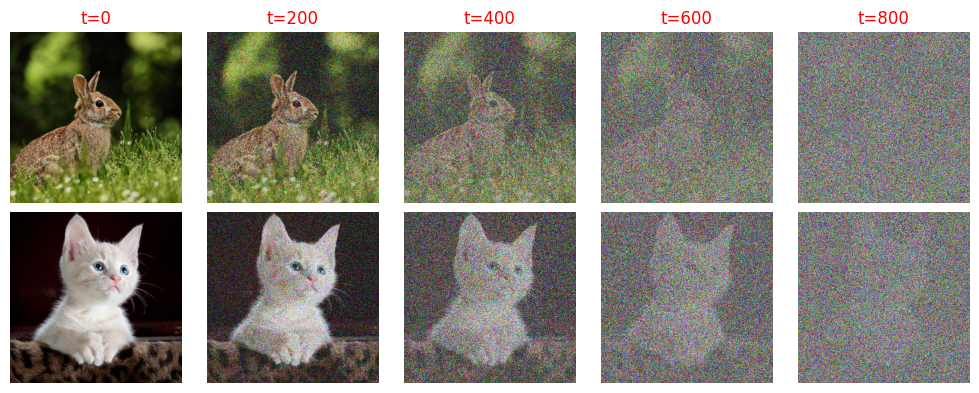

In [3]:
# answer to exercise 5.1
imgs=[]
for name in ["bunny", "cat"]:
    img=np.array(PIL.Image.open(f"files/{name}.png"))
    img=torch.tensor(2*(img/255)-1)
    for timestep in [0,250,500,750,1000]:    #B
        imgs.append(linear_noisy_image(img,timestep)/2+0.5)
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    plt.subplot(2,5,i+1)    #C
    plt.imshow(imgs[i])
    if i<5:
        plt.title(f't={200*(i%6)}',fontsize=12,c="r")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 1.3 Different Diffusion Schedules


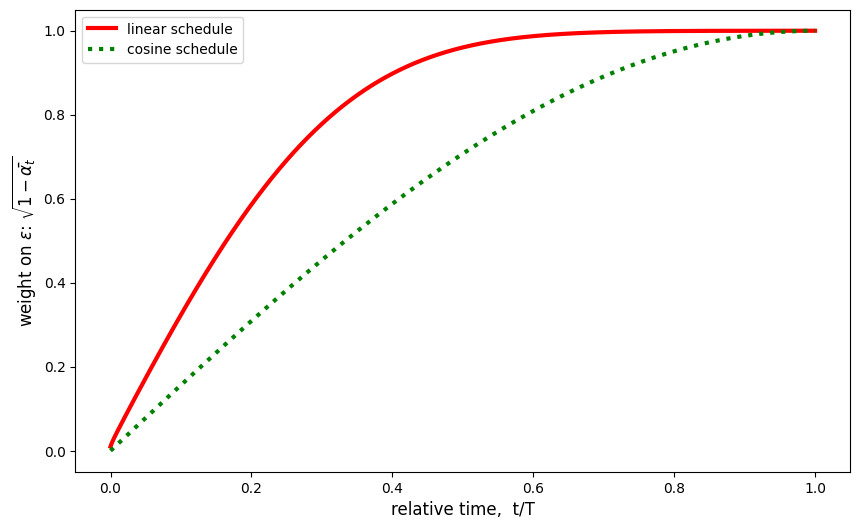

In [4]:
import math
def cosine_scheduler():    #A
    sqrtab = torch.cos(0.5*math.pi*t)
    sqrtmab = torch.sin(0.5*math.pi*t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtmab"], linewidth=3,    #B 
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtmab"], linewidth=3,    #C 
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time,  t/T", fontsize=12)
plt.ylabel(r"weight on $\epsilon$: $\sqrt{1-\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()


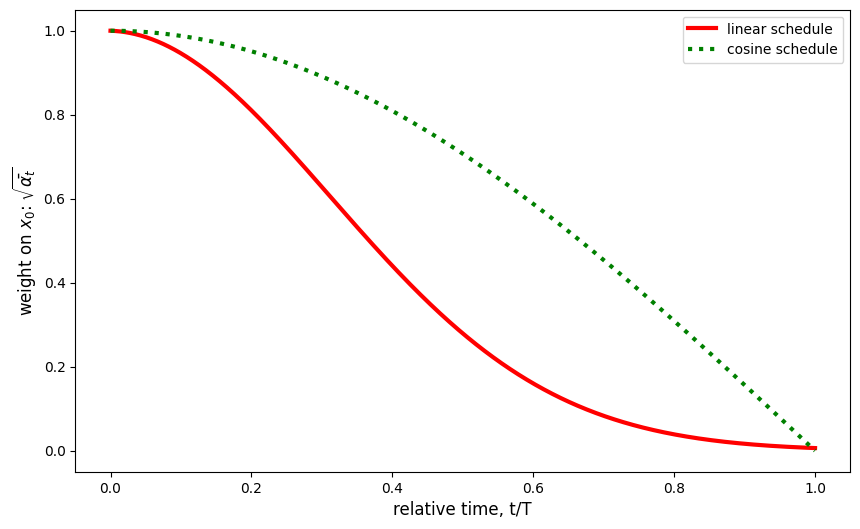

In [5]:
plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtab"], linewidth=3,    #A 
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtab"], linewidth=3,    #B 
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time, t/T", fontsize=12)
plt.ylabel(r"weight on $x_0$: $\sqrt{\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()


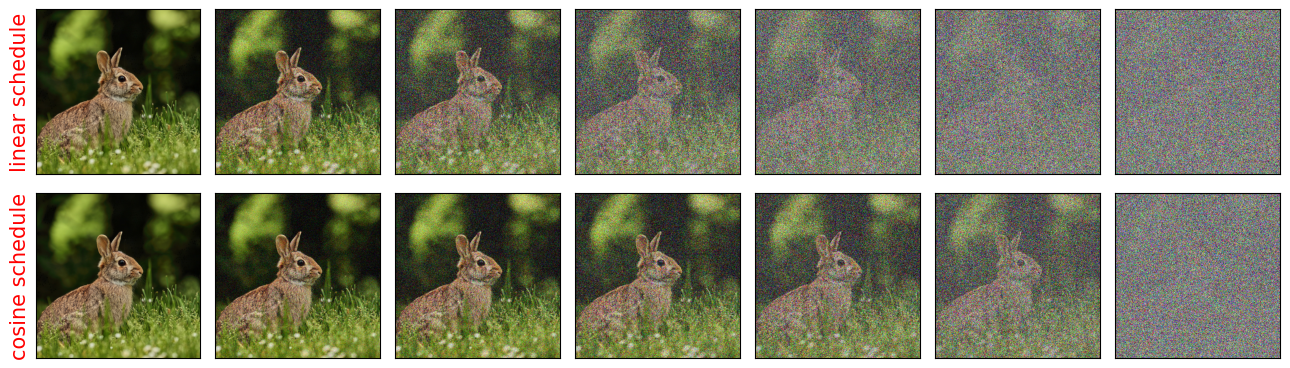

In [6]:
def cosine_noisy_image(image,timestep):    #A
    alphabar_t=cosine_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)

img=np.array(PIL.Image.open("files/bunny.png"))
img=torch.tensor(2*(img/255)-1)
imgs=[]

for timestep in [0,166,332,498,664,830,996]:    #B
    imgs.append(linear_noisy_image(img,timestep)/2+0.5)
for timestep in [0,166,332,498,664,830,996]:    #C
    imgs.append(cosine_noisy_image(img,timestep)/2+0.5)

plt.figure(figsize=(13,4),dpi=100)
for i in range(14):    #D
    plt.subplot(2,7,i+1) 
    plt.imshow(imgs[i])
    plt.xticks([])
    plt.yticks([])
    if i==0:
        plt.ylabel("linear schedule",fontsize=15,c="r")
    if i==7:
        plt.ylabel("cosine schedule",fontsize=15,c="r")
plt.tight_layout()
plt.show()


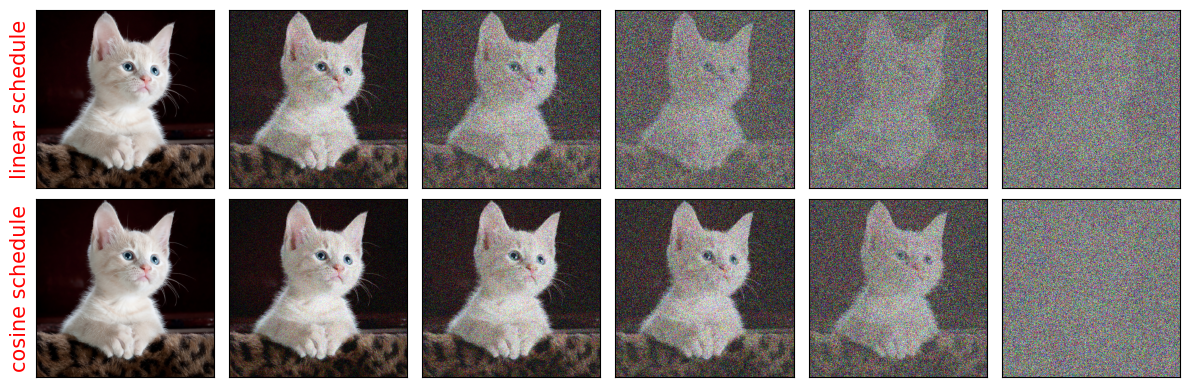

In [7]:
# answer to exercise 5.2
img=np.array(PIL.Image.open("files/cat.png"))
img=torch.tensor(2*(img/255)-1)
imgs=[]

for timestep in [0, 199, 399, 599, 799, 999 ]:    #B
    imgs.append(linear_noisy_image(img,timestep)/2+0.5)
for timestep in [0, 199, 399, 599, 799, 999]:    #C
    imgs.append(cosine_noisy_image(img,timestep)/2+0.5)

plt.figure(figsize=(12,4),dpi=100)
for i in range(12):    #D
    plt.subplot(2,6,i+1) 
    plt.imshow(imgs[i])
    plt.xticks([])
    plt.yticks([])
    if i==0:
        plt.ylabel("linear schedule",fontsize=15,c="r")
    if i==6:
        plt.ylabel("cosine schedule",fontsize=15,c="r")
plt.tight_layout()
plt.show()

# 2 The Reverse Diffusion Process 


In [8]:
import diffusers, torch

device="cuda" if torch.cuda.is_available() else "cpu"
model=diffusers.UNet2DModel(sample_size=32,    #A
                    in_channels=1,
                    out_channels=1,layers_per_block=2,
    block_out_channels=(128,128,256,512),    #B
    down_block_types=("DownBlock2D","DownBlock2D",    #C
                      "AttnDownBlock2D","DownBlock2D",),
    up_block_types=("UpBlock2D","AttnUpBlock2D",    #D
                "UpBlock2D","UpBlock2D",),).to(device)


# 3. A blueprint to train the U-Net model

## 3.1	Steps in training a denoising U-Net model

# 3.2 Preprocess the training data


In [9]:
from torchvision import transforms

torch.manual_seed(42)    #A

tf = transforms.Compose(
    [transforms.Resize((32,32)),transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),]    #B
)


The manual_seed() method in PyTorch is used to fix the random state so that results are
reproducible. The transforms package in Torchvision can help create a series of transformations to
preprocess images. We resize the images from (1, 28, 28) to (1, 32, 32) so that the images fit the input dimensions of the 
U-Net model we created in the last section. The ToTensor() class converts image data (in either PIL image formats or NumPy
arrays) into PyTorch tensors. In particular, the image data are integers ranging from 0 to 255 and
the ToTensor() class converts them to float tensors with values in the range of 0.0 and 1.0.
We then normalize the input
data to the range [-1, 1] for faster convergence during training and you’ll do this often in this
book.

Next, we use the datasets package in Torchvision to download the dataset to a folder on your
computer and perform the transformation, like so:

In [10]:
import torchvision

dataset = torchvision.datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,
)

There are ten different types of
clothing items. The labels in the dataset are numbered from 0 to 9. The list text_labels below contains the ten text labels
corresponding to the numerical labels 0 to 9. For example, if an item has a numerical label of 0 in
the dataset, the corresponding text label is "t-shirt". The list text_labels is defined as follows:

In [11]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

We can plot the data to visualize the clothes items in the dataset:

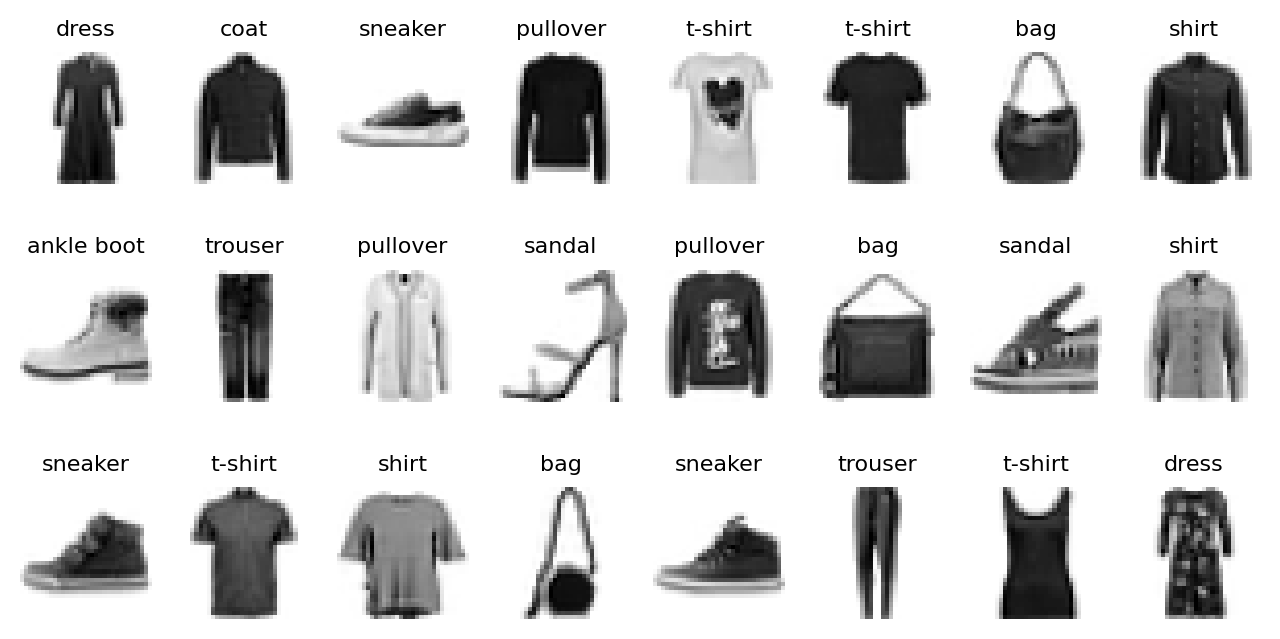

In [12]:
import matplotlib.pyplot as plt
plt.figure(dpi=200,figsize=(8,4))
for i in range(24):
    ax=plt.subplot(3, 8, i + 1) 
    img=dataset[i+888][0] 
    img=img/2+0.5 
    img=img.reshape(32,32) 
    plt.imshow(img,
    cmap="binary")
    plt.axis('off')
    plt.title(text_labels[dataset[i+888][1]],fontsize=8)
plt.show()


Finally, we put the training data in batches, as follows:

In [13]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# 4. Train and Use the Diffusion Model


## 4.1 The DDPM Noise Scheduler


In [14]:
noise_scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=1000,
  beta_schedule="squaredcos_cap_v2")

## 4.2 Inference using the U-Net denosing model


In [15]:
# sampling
@torch.no_grad()
def sample(n_sample, model, noise_scheduler,seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    noise_scheduler.set_timesteps(1000)
    image=torch.randn((n_sample,1,32,32)).to(device)
    for t in noise_scheduler.timesteps:
        model_output=model(image,t)['sample']
        image=noise_scheduler.step(model_output,int(t),
                       image,generator=None)['prev_sample']        
    return image

## 4.3 Train and use the denoising U-Net model


In [16]:
optim = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [17]:
from tqdm import tqdm
from torchvision.utils import save_image, make_grid

scaler = torch.amp.GradScaler("cuda")
for i in range(10):    #A    
    pbar = tqdm(dataloader)
    loss_ema = None
    for x, _ in pbar:
        x = x.to(device)
        with torch.amp.autocast("cuda"):
            noise=torch.randn_like(x).to(device)
            timesteps=torch.randint(0,
                    noise_scheduler.config.num_train_timesteps,
                                    (x.shape[0],),device=device)
            noisy=noise_scheduler.add_noise(x, noise, timesteps)
            noise_pred=model(noisy,timesteps)["sample"]    #B
            loss = torch.nn.functional.l1_loss(noise_pred,noise)    
        optim.zero_grad() 
        scaler.scale(loss).backward()    #C
        scaler.step(optim)
        scaler.update()
        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.9 * loss_ema + 0.1 * loss.item()
        pbar.set_description(f"loss: {loss_ema:.4f}")
    xh = sample(32, model, noise_scheduler)
    grid = make_grid(0.5-xh/2, nrow=8)    #D
    save_image(grid, f"files/diffusion_fashion{i}.png")
torch.save(model.state_dict(), "files/diffusion_fashion.pth")


The training takes about 30 minutes if you use GPU training. Otherwise, it takes a few hours. The trained model is saved on your computer. Alternatively, you can download the trained model from my Google drive here https://drive.google.com/file/d/1YQdV-bF9sp_tJkd7jReIfv3MeyfnMaB3/view?usp=sharing. Unzip the file after downloading.

Let's load up the trained model and generate some images: 

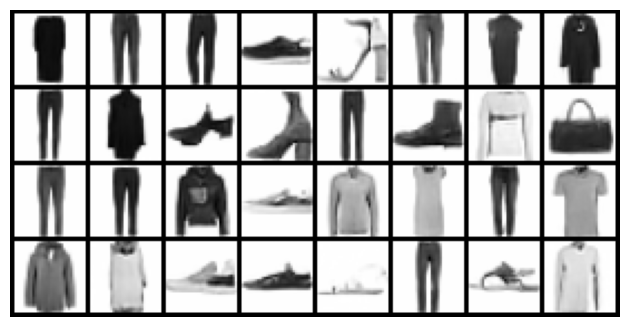

In [18]:
torch.manual_seed(42)
model.load_state_dict(torch.load(
    "files/diffusion_fashion.pth",
         map_location=device,
         weights_only=True))    #A
generated_images = sample(32, model, noise_scheduler)    #B
grid = make_grid(0.5-generated_images/2, nrow=8)
save_image(grid, f"files/diffusion_fashion.png")
plt.figure(dpi=100)
plt.imshow(grid.cpu().permute(1,2,0))    #C
plt.axis('off')
plt.tight_layout()
plt.show()


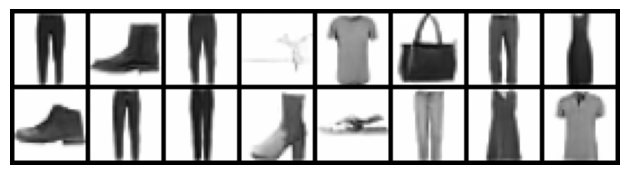

In [19]:
# answer to exercise 5.3
torch.manual_seed(0)

generated_images = sample(16, model, noise_scheduler)    
grid = make_grid(0.5-generated_images/2, nrow=8)

plt.figure(dpi=100)
plt.imshow(grid.cpu().permute(1,2,0))    
plt.axis('off')
plt.tight_layout()
plt.show()
